# Meme Yoğunluğu (Breast Density) Segmentasyonu — Ortak Eğitim Notebook'u

Bu notebook 6 mimarinin hepsi için ortak şablondur (bkz. `PLAN.md`). Farklı bir model
eğitmek için sadece **CONFIG** hücresindeki `MODEL_KEY` değiştirilip notebook Colab'da
"Save a copy as" ile yeni isimle kaydedilir (`mass_lezyon_projesi` notebook'larındaki
desenin aynısı — MODEL_NAME değişir, geri kalan hücreler aynı kalır).

Sıra: kurulum → veri → augmentation → model → loss/metrik → log/checkpoint yardımcıları
→ eğitim döngüsü → final değerlendirme → grafikler → 5 vaka görseli.

In [51]:
!pip -q install segmentation-models-pytorch transformers albumentations torchmetrics nibabel openpyxl

In [52]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, json, random, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation

import torchmetrics.functional as TMF

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


## CONFIG — deney başına burada değiştirilir

In [53]:
# ---- HER MODEL ICIN SABIT SEMA, SADECE MODEL_KEY DEGISIR ----
MODEL_KEY = 'segformer_b2'  # secenekler asagida MODEL_CONFIGS icinde

# LR degerleri literatur taramasiyla belirlendi (bkz. konusma / PLAN.md):
# - U-Net / U-Net++ + ResNet34/EfficientNet-B0: encoder 5e-5 (kucuk medikal veri
#   setlerinde yaygin), decoder 5x encoder
# - DeepLabV3+ + ResNet50/EfficientNet-B3: encoder 1e-4, decoder 5x encoder
# - SegFormer-B2: tek LR 1e-4 (AdamW, transformer fine-tuning), ayri encoder/decoder LR yok
MODEL_CONFIGS = {
    'unet_resnet34':        dict(arch='unet',       encoder='resnet34',        batch_size=16, lr_encoder=5e-5, lr_decoder=2.5e-4, max_epochs=70, patience=15),
    'unet_effnetb0':        dict(arch='unet',       encoder='efficientnet-b0', batch_size=16, lr_encoder=5e-5, lr_decoder=2.5e-4, max_epochs=70, patience=15),
    'unetpp_resnet34':      dict(arch='unetpp',     encoder='resnet34',        batch_size=12, lr_encoder=5e-5, lr_decoder=2.5e-4, max_epochs=70, patience=15),
    'deeplabv3p_resnet50':  dict(arch='deeplabv3p', encoder='resnet50',        batch_size=8,  lr_encoder=1e-4, lr_decoder=5e-4,   max_epochs=70, patience=15),
    'deeplabv3p_effnetb3':  dict(arch='deeplabv3p', encoder='efficientnet-b3', batch_size=8,  lr_encoder=1e-4, lr_decoder=5e-4,   max_epochs=70, patience=15),
    'segformer_b2':         dict(arch='segformer',  encoder=None,              batch_size=8,  lr_encoder=None, lr_decoder=1e-4,   max_epochs=70, patience=15),
}

CFG = MODEL_CONFIGS[MODEL_KEY]
CFG['model_key'] = MODEL_KEY

SEED = 42
IMAGE_SIZE = 512
WARMUP_EPOCHS = 3  # ilk 3 epoch: LR hedefe kademeli cikar, sonra ReduceLROnPlateau devreye girer
WEIGHT_DECAY = 1e-4
NUM_EVAL_CASES = 5

# ---- Veri yolu ----
DATA_ROOT = '/content/drive/MyDrive/Mendeley_Data_Density_Entegrasyonu'
IMAGES_TR, LABELS_TR = f'{DATA_ROOT}/imagesTr', f'{DATA_ROOT}/labelsTr'
IMAGES_VAL, LABELS_VAL = f'{DATA_ROOT}/imagesVal', f'{DATA_ROOT}/labelsVal'
TRAIN_DENSITY_JSON = f'{DATA_ROOT}/train_density.json'
VAL_DENSITY_JSON = f'{DATA_ROOT}/val_density.json'

# ---- Cikti yollari (Drive kalici + yerel ayna, mass_lezyon_projesi ile ayni desen) ----
DRIVE_DIR = f'/content/drive/MyDrive/density_segmentation/{MODEL_KEY}'
LOCAL_DIR = f'/content/outputs/{MODEL_KEY}'
CKPT_DIR = f'{DRIVE_DIR}/checkpoints'
CASES_DIR = f'{DRIVE_DIR}/{MODEL_KEY}_cases'
EVAL_CASES_PATH = '/content/drive/MyDrive/density_segmentation/eval_cases.json'  # tum modeller ortak, 5 sabit vaka

for d in [DRIVE_DIR, LOCAL_DIR, CKPT_DIR, CASES_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

EXCEL_LOG = f'{DRIVE_DIR}/{MODEL_KEY}_log.xlsx'
CURVES_PNG = f'{DRIVE_DIR}/{MODEL_KEY}_curves.png'
TEST_SUMMARY_XLSX = f'{DRIVE_DIR}/{MODEL_KEY}_test_summary.xlsx'
LAST_CKPT = f'{CKPT_DIR}/last.pt'
BEST_CKPT = f'{CKPT_DIR}/best.pt'

# resume kontrolu: sadece egitim kesildiyse ve devam etmek istiyorsan True yap
RESUME = False

print('MODEL_KEY:', MODEL_KEY)
print('CFG:', CFG)
print('Drive cikti:', DRIVE_DIR)


def mirror_to_local(drive_path):
    # Drive'daki bir cikti dosyasini ayni adla yerel aynaya kopyala
    dst = Path(LOCAL_DIR) / Path(drive_path).name
    shutil.copy2(drive_path, dst)
    return str(dst)

MODEL_KEY: segformer_b2
CFG: {'arch': 'segformer', 'encoder': None, 'batch_size': 8, 'lr_encoder': None, 'lr_decoder': 0.0001, 'max_epochs': 70, 'patience': 15, 'model_key': 'segformer_b2'}
Drive cikti: /content/drive/MyDrive/density_segmentation/segformer_b2


## Tekrarlanabilirlik

In [54]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

## Veri: case eşleştirme + density json

In [55]:
def build_case_index(images_dir, labels_dir):
    # nnU-Net stili klasorlerde imagesTr dosyalari bazen '<case>_0000.nii.gz' olarak
    # gecer (kanal/modalite soneki), labelsTr ise '<case>.nii.gz'. Ikisini de
    # destekleyecek sekilde soneki temizleyip case_id'ye gore eslestiriyoruz.
    def stem(p):
        name = os.path.basename(p)
        for suf in ('.nii.gz',):
            if name.endswith(suf):
                name = name[: -len(suf)]
        if name.endswith('_0000'):
            name = name[: -len('_0000')]
        return name

    img_files = sorted(glob.glob(f'{images_dir}/*.nii.gz'))
    lbl_files = sorted(glob.glob(f'{labels_dir}/*.nii.gz'))
    img_map = {stem(p): p for p in img_files}
    lbl_map = {stem(p): p for p in lbl_files}

    common = sorted(set(img_map) & set(lbl_map))
    missing = sorted(set(img_map) ^ set(lbl_map))
    if missing:
        print(f'UYARI: {len(missing)} case imagesTr/labelsTr arasinda eslesmedi, ornek: {missing[:5]}')
    return [(cid, img_map[cid], lbl_map[cid]) for cid in common]


def load_density_map(json_path):
    with open(json_path) as f:
        return json.load(f)


train_index = build_case_index(IMAGES_TR, LABELS_TR)
val_index = build_case_index(IMAGES_VAL, LABELS_VAL)
train_density = load_density_map(TRAIN_DENSITY_JSON)
val_density = load_density_map(VAL_DENSITY_JSON)

print('Train case sayisi:', len(train_index))
print('Val case sayisi:', len(val_index))
assert len(train_index) > 0 and len(val_index) > 0, 'Case eslesmedi -- dosya adi seonekini kontrol et.'

Train case sayisi: 447
Val case sayisi: 89


## Dataset + Augmentation

In [56]:
# Goruntu Dataset icinde min-max ile [0,1]'e cekiliyor. A.Normalize varsayilan
# max_pixel_value=255 ile bir kez daha bolerse dinamik aralik 1/255'e iner ve
# encoder'a neredeyse sabit bir duzlem gider -- bu yuzden 1.0 veriliyor.
def imagenet_normalize():
    return A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=1.0)


def get_train_transform(size):
    return A.Compose([
        A.Resize(size, size),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=15, p=0.5, border_mode=0),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
        A.ElasticTransform(alpha=30, sigma=15, p=0.2),  # alpha=1 deformasyon uretmiyordu
        A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(8, 24), hole_width_range=(8, 24), p=0.2),
        imagenet_normalize(),
        ToTensorV2(),
    ])


def get_val_transform(size):
    return A.Compose([
        A.Resize(size, size),
        imagenet_normalize(),
        ToTensorV2(),
    ])


# Her epoch 447 .nii.gz dosyasini Drive'dan okumak egitimin en yavas kismi;
# ilk okumada yerel diske .npy yazip sonraki epochlarda oradan okuyoruz
CACHE_DIR = '/content/npy_cache'
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)


def load_volume(path, cache_key):
    cache_path = f'{CACHE_DIR}/{cache_key}.npy'
    if os.path.exists(cache_path):
        return np.load(cache_path)
    arr = nib.load(path).get_fdata().astype(np.float32)
    # DataLoader worker'lari ayni dosyayi yazabilir; yarim dosya okunmasin diye atomik yaz
    tmp_path = f'{cache_path}.{os.getpid()}.tmp'
    with open(tmp_path, 'wb') as f:
        np.save(f, arr)
    os.replace(tmp_path, cache_path)
    return arr


class DensityDataset(Dataset):
    def __init__(self, index, density_map, transform):
        self.index = index  # list of (case_id, img_path, lbl_path)
        self.density_map = density_map
        self.transform = transform

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        case_id, img_path, lbl_path = self.index[idx]
        img = load_volume(img_path, f'{case_id}_img')
        lbl = load_volume(lbl_path, f'{case_id}_lbl')

        # per-goruntu min-max normalizasyon (ham piksel araligi dosyadan
        # dosyaya degisebiliyor, sabit bir global max varsayilmiyor)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img_3ch = np.stack([img, img, img], axis=-1)  # HWC, ImageNet on-egitimli encoder icin

        augmented = self.transform(image=img_3ch, mask=lbl)
        image = augmented['image']
        mask = augmented['mask']
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        mask = mask.float()

        density = float(self.density_map.get(case_id, -1.0))
        return image, mask, case_id, density


train_ds = DensityDataset(train_index, train_density, get_train_transform(IMAGE_SIZE))
val_ds = DensityDataset(val_index, val_density, get_val_transform(IMAGE_SIZE))

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CFG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

print('Train batch sayisi:', len(train_loader), '| Val batch sayisi:', len(val_loader))

# Normalize duzeltmesinin dogrulamasi: girdi araligi ~[-2.1, 2.6] olmali,
# tumu -2.1 civarinda sikismis geliyorsa max_pixel_value hala yanlis demektir
_img, _mask, _, _ = val_ds[0]
print(f'Girdi tensor araligi: [{_img.min():.3f}, {_img.max():.3f}] | maske degerleri: {torch.unique(_mask).tolist()}')

Train batch sayisi: 55 | Val batch sayisi: 12
Girdi tensor araligi: [-2.118, 2.640] | maske degerleri: [0.0, 1.0]


## Model Factory (6 mimari, tek arayuz)

In [58]:
class SegWrapper(nn.Module):
    # tum modelleri ayni forward arayuzune (B,1,H,W logit) indirger,
    # SegFormer'in dusuk cozunurluklu ciktisini girdi boyutuna yukseltir
    def __init__(self, model, is_segformer=False):
        super().__init__()
        self.model = model
        self.is_segformer = is_segformer

    def forward(self, x):
        if self.is_segformer:
            out = self.model(pixel_values=x).logits
            out = F.interpolate(out, size=x.shape[-2:], mode='bilinear', align_corners=False)
            return out
        return self.model(x)


def build_model(model_key):
    arch = MODEL_CONFIGS[model_key]['arch']
    encoder = MODEL_CONFIGS[model_key]['encoder']

    if arch == 'unet':
        m = smp.Unet(encoder_name=encoder, encoder_weights='imagenet', in_channels=3, classes=1)
        return SegWrapper(m)
    if arch == 'unetpp':
        m = smp.UnetPlusPlus(encoder_name=encoder, encoder_weights='imagenet', in_channels=3, classes=1)
        return SegWrapper(m)
    if arch == 'deeplabv3p':
        m = smp.DeepLabV3Plus(encoder_name=encoder, encoder_weights='imagenet', in_channels=3, classes=1)
        return SegWrapper(m)
    if arch == 'segformer':
        m = SegformerForSemanticSegmentation.from_pretrained(
            'nvidia/segformer-b2-finetuned-ade-512-512',
            num_labels=1, ignore_mismatched_sizes=True)
        return SegWrapper(m, is_segformer=True)
    raise ValueError(f'Bilinmeyen arch: {arch}')


def build_optimizer(model, cfg):
    if cfg['model_key'] == 'segformer_b2':
        return torch.optim.AdamW(model.parameters(), lr=cfg['lr_decoder'], weight_decay=WEIGHT_DECAY)
    encoder_params = list(model.model.encoder.parameters())
    encoder_ids = set(id(p) for p in encoder_params)
    decoder_params = [p for p in model.parameters() if id(p) not in encoder_ids]
    return torch.optim.AdamW([
        {'params': encoder_params, 'lr': cfg['lr_encoder']},
        {'params': decoder_params, 'lr': cfg['lr_decoder']},
    ], weight_decay=WEIGHT_DECAY)


# BatchNorm momentum'u varsayilan (0.1) birakildi. Bir ara 0.01'e cekilmisti ama
# asil dengesizlik yanlis Normalize'dan geliyordu; epoch basina 27 adim varken
# 0.01 running istatistiklerin oturmasini ~4 epoch geciktiriyor.
model = build_model(MODEL_KEY).to(DEVICE)

optimizer = build_optimizer(model, CFG)
TARGET_LRS = [g['lr'] for g in optimizer.param_groups]  # warmup rampasi icin hedef LR'ler

# ReduceLROnPlateau: kucuk medikal veri setlerinde cosine annealing'den daha
# yaygin -- val loss 3 epoch iyilesmezse LR x0.5, min_lr 1e-7 ile taban belirlenir
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-7
)

scaler = torch.amp.GradScaler('cuda')

n_params = sum(p.numel() for p in model.parameters())
print(f'{MODEL_KEY} parametre sayisi: {n_params:,}')

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([1])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


segformer_b2 parametre sayisi: 27,347,393


## Loss ve Metrikler (Dice+BCE, Dice/IoU/Precision/Recall/F1)

In [59]:
def dice_bce_loss(logits, targets, smooth=1.0):
    # AMP altinda logits fp16 gelir. probs.sum() 512x512=262144 piksel uzerinden
    # alindigi icin ortalama olasilik ~0.25'i gectiginde fp16 tavanini (65504)
    # asip inf'e doner; o zaman dice=0, dice_loss=1 sabitlenir ve gradyan uretmez.
    # Bu tam da yuksek yogunluklu vakalarda (dens alan genis) devreye girer,
    # yani Dice terimi en cok gerektigi yerde sessizce kapaniyordu.
    logits = logits.float()
    targets = targets.float()

    bce = F.binary_cross_entropy_with_logits(logits, targets)
    probs = torch.sigmoid(logits)
    probs_flat = probs.reshape(probs.size(0), -1)
    targets_flat = targets.reshape(targets.size(0), -1)
    intersection = (probs_flat * targets_flat).sum(dim=1)
    dice = (2 * intersection + smooth) / (probs_flat.sum(dim=1) + targets_flat.sum(dim=1) + smooth)
    dice_loss = 1 - dice.mean()
    return bce + dice_loss


@torch.no_grad()
def compute_metrics(logits, targets, threshold=0.5, eps=1.0):
    # Tum metrikler goruntu basina hesaplanip batch icinde ortalaniyor.
    # Onceden Dice goruntu basina, digerleri torchmetrics ile batch-geneli
    # (micro) hesaplaniyordu; binary'de esit olmasi gereken Dice ve F1 ayrisiyordu.
    preds = (torch.sigmoid(logits.float()) > threshold).float()
    targets = (targets > 0.5).float()

    preds_flat = preds.reshape(preds.size(0), -1)
    targets_flat = targets.reshape(targets.size(0), -1)

    tp = (preds_flat * targets_flat).sum(dim=1)
    fp = (preds_flat * (1 - targets_flat)).sum(dim=1)
    fn = ((1 - preds_flat) * targets_flat).sum(dim=1)

    dice = ((2 * tp + eps) / (2 * tp + fp + fn + eps)).mean().item()
    iou = ((tp + eps) / (tp + fp + fn + eps)).mean().item()
    precision = ((tp + eps) / (tp + fp + eps)).mean().item()
    recall = ((tp + eps) / (tp + fn + eps)).mean().item()
    return dict(dice=dice, iou=iou, precision=precision, recall=recall, f1=dice)  # binary'de F1 = Dice


## Excel log ve grafik yardımcıları (mass_lezyon_projesi ile aynı desen)

In [60]:
SCHEMA = ['epoch', 'train_loss', 'val_loss', 'dice', 'iou', 'precision', 'recall', 'f1', 'lr']

# 6 modelin figurleri yan yana konuldugunda gorsel olarak karsilastirilabilsin diye
# metrik panelleri sabit olcekte. Otomatik olcekte recall paneli 0.72-0.92 arasina
# zoomlanip +-0.1'lik dalgalanmayi kararsizlik gibi gosteriyordu.
METRIC_YLIM = (0.0, 1.0)


def append_epoch_row(excel_path, row, resume_epoch=None):
    # resume'da tekrari onlemek icin resume_epoch ve sonrasini at
    if os.path.exists(excel_path):
        df = pd.read_excel(excel_path)
        if resume_epoch is not None:
            df = df[df['epoch'] < resume_epoch]
        rows = df.to_dict('records')
    else:
        rows = []
    clean = {k: row.get(k, None) for k in SCHEMA}
    rows.append(clean)
    pd.DataFrame(rows)[SCHEMA].to_excel(excel_path, index=False)
    return len(rows)


def plot_training_curves(excel_path, out_path, model_name):
    df = pd.read_excel(excel_path)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    ax = axes[0, 0]
    ax.plot(df['epoch'], df['train_loss'], marker='o', markersize=3, label='Train')
    ax.plot(df['epoch'], df['val_loss'], marker='o', markersize=3, label='Val')
    ax.set_title('Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_ylim(0, None); ax.legend(); ax.grid(alpha=0.3)

    for ax, col, title, ylabel, color in [
        (axes[0, 1], 'dice',      'Dice Score',    'Dice',      'tab:green'),
        (axes[0, 2], 'iou',       'IoU (Jaccard)', 'IoU',       'tab:purple'),
        (axes[1, 0], 'precision', 'Precision',     'Precision', 'tab:orange'),
        (axes[1, 1], 'recall',    'Recall',        'Recall',    'tab:red'),
    ]:
        ax.plot(df['epoch'], df[col], marker='o', markersize=3, color=color)
        ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_ylim(*METRIC_YLIM); ax.grid(alpha=0.3)

    # F1 binary'de Dice ile ozdes oldugu icin ayri panel bilgi tasimiyordu;
    # yerine LR takvimi -- Dice sicramalarinin LR dususleriyle hizalandigi burada gorulur
    ax = axes[1, 2]
    ax.plot(df['epoch'], df['lr'], marker='o', markersize=3, color='tab:brown')
    ax.set_yscale('log')
    ax.set_title('Learning Rate (decoder)'); ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
    ax.grid(alpha=0.3, which='both')

    plt.suptitle(f'{model_name} Egitim Egrileri   (F1 = Dice: binary segmentasyonda ozdes)', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()

## Checkpoint / Resume

In [61]:
def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, best_dice, epochs_without_improve=0):
    torch.save({
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler': scaler.state_dict(),
        'epoch': epoch,
        'best_dice': best_dice,
        'epochs_without_improve': epochs_without_improve,  # resume'da early stopping sayaci sifirlanmasin
        'torch_rng_state': torch.get_rng_state(),
        'numpy_rng_state': np.random.get_state(),
    }, path)


def restore_checkpoint(ckpt, model, optimizer, scheduler, scaler):
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    scaler.load_state_dict(ckpt['scaler'])
    torch.set_rng_state(ckpt['torch_rng_state'].cpu())
    np.random.set_state(ckpt['numpy_rng_state'])
    return ckpt['epoch'], ckpt['best_dice'], ckpt.get('epochs_without_improve', 0)


def find_resumable_checkpoint():
    # last.pt icinde epoch/optimizer bilgisi olmadan resume edilirse
    # sessizce yanlis (sifirdan) baslar -- once dogrula, yoksa acikca hata ver
    if not os.path.exists(LAST_CKPT):
        raise FileNotFoundError(f'Resume edilebilir checkpoint yok: {LAST_CKPT}')
    ckpt = torch.load(LAST_CKPT, map_location=DEVICE, weights_only=False)
    if 'epoch' not in ckpt or 'optimizer' not in ckpt:
        raise RuntimeError(f'{LAST_CKPT} eksik/bozuk -- resume edilemez.')
    return ckpt

## 5 sabit değerlendirme vakası (tüm modellerde ortak)

In [62]:
def get_or_create_eval_cases(val_index, n=NUM_EVAL_CASES, seed=SEED):
    if os.path.exists(EVAL_CASES_PATH):
        with open(EVAL_CASES_PATH) as f:
            return json.load(f)
    rng = random.Random(seed)
    case_ids = [c[0] for c in val_index]
    chosen = rng.sample(case_ids, k=min(n, len(case_ids)))
    Path(EVAL_CASES_PATH).parent.mkdir(parents=True, exist_ok=True)
    with open(EVAL_CASES_PATH, 'w') as f:
        json.dump(chosen, f, indent=2)
    return chosen


EVAL_CASE_IDS = get_or_create_eval_cases(val_index)
print('Degerlendirme vakalari (tum modellerde ayni):', EVAL_CASE_IDS)

Degerlendirme vakalari (tum modellerde ayni): ['0953b01dfcb2ae000cae0a10b610fdcd', '0228a0c3c65d83e70bf133e5ce5adb0f', '01063a8571b3ed30201ea2e220c50d53', '0499c489fd29c07f4ed75e296aa54107', '0404ee33246fdae4dac260b64fd11623']


## Eğitim Döngüsü

In [63]:
def train_one_epoch():
    model.train()
    total_loss = 0.0
    n_seen = 0
    for images, masks, _, _ in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            logits = model(images)
            loss = dice_bce_loss(logits, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
        n_seen += images.size(0)
    return total_loss / n_seen  # drop_last=True yuzunden dataset boyutundan az ornek gorulur


@torch.no_grad()
def validate_one_epoch():
    model.eval()
    total_loss = 0.0
    n_seen = 0
    agg = dict(dice=0.0, iou=0.0, precision=0.0, recall=0.0, f1=0.0)
    for images, masks, _, _ in val_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        with torch.amp.autocast('cuda'):
            logits = model(images)
            loss = dice_bce_loss(logits, masks)
        total_loss += loss.item() * images.size(0)
        n_seen += images.size(0)
        m = compute_metrics(logits, masks)
        for k in agg:
            agg[k] += m[k] * images.size(0)
    val_loss = total_loss / n_seen
    for k in agg:
        agg[k] /= n_seen
    return val_loss, agg

In [64]:
start_epoch = 0
best_dice = -1.0
epochs_without_improve = 0

if RESUME:
    resume_ckpt = find_resumable_checkpoint()
    last_epoch, best_dice, epochs_without_improve = restore_checkpoint(
        resume_ckpt, model, optimizer, scheduler, scaler)
    start_epoch = last_epoch + 1
    print(f'Resume: epoch {start_epoch} itibariyle devam, best_dice={best_dice:.4f}, '
          f'iyilesmeyen epoch={epochs_without_improve}')
else:
    if os.path.exists(EXCEL_LOG):
        os.remove(EXCEL_LOG)
        print(f'Eski log silindi: {EXCEL_LOG}')
    print('Sifirdan egitim basliyor.')

for epoch in range(start_epoch, CFG['max_epochs']):
    if epoch < WARMUP_EPOCHS:
        # linear warmup: LR hedefin (epoch+1)/WARMUP_EPOCHS orani kadarina cikar
        warmup_factor = (epoch + 1) / WARMUP_EPOCHS
        for g, base_lr in zip(optimizer.param_groups, TARGET_LRS):
            g['lr'] = base_lr * warmup_factor

    train_loss = train_one_epoch()
    val_loss, val_metrics = validate_one_epoch()

    if epoch >= WARMUP_EPOCHS:
        # ReduceLROnPlateau sadece warmup bittikten sonra devreye girer,
        # boylece patience sayaci warmup donemindeki gurultuden etkilenmez
        scheduler.step(val_loss)
    current_lr = optimizer.param_groups[-1]['lr']

    row = dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss, lr=current_lr, **val_metrics)
    append_epoch_row(EXCEL_LOG, row, resume_epoch=start_epoch if epoch == start_epoch else None)

    improved = val_metrics['dice'] > best_dice
    if improved:
        best_dice = val_metrics['dice']
        epochs_without_improve = 0
        save_checkpoint(BEST_CKPT, model, optimizer, scheduler, scaler, epoch, best_dice, epochs_without_improve)
    else:
        epochs_without_improve += 1

    save_checkpoint(LAST_CKPT, model, optimizer, scheduler, scaler, epoch, best_dice, epochs_without_improve)

    print(f"Epoch {epoch:03d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | "
          f"dice {val_metrics['dice']:.4f} | iou {val_metrics['iou']:.4f} | "
          f"best_dice {best_dice:.4f}{' *' if improved else ''}")

    if epochs_without_improve >= CFG['patience']:
        print(f'Early stopping: {CFG["patience"]} epoch boyunca val Dice iyilesmedi.')
        break

mirror_to_local(EXCEL_LOG)
print('Egitim bitti. En iyi val Dice:', best_dice)

Sifirdan egitim basliyor.
Epoch 000 | train_loss 1.4094 | val_loss 1.2170 | dice 0.5101 | iou 0.3618 | best_dice 0.5101 *
Epoch 001 | train_loss 1.1213 | val_loss 0.9296 | dice 0.6416 | iou 0.4961 | best_dice 0.6416 *
Epoch 002 | train_loss 0.8457 | val_loss 0.6923 | dice 0.6795 | iou 0.5383 | best_dice 0.6795 *
Epoch 003 | train_loss 0.6435 | val_loss 0.5617 | dice 0.6909 | iou 0.5524 | best_dice 0.6909 *
Epoch 004 | train_loss 0.5106 | val_loss 0.4441 | dice 0.7193 | iou 0.5836 | best_dice 0.7193 *
Epoch 005 | train_loss 0.4338 | val_loss 0.3869 | dice 0.7456 | iou 0.6152 | best_dice 0.7456 *
Epoch 006 | train_loss 0.3865 | val_loss 0.3774 | dice 0.7325 | iou 0.5975 | best_dice 0.7456
Epoch 007 | train_loss 0.3598 | val_loss 0.3357 | dice 0.7631 | iou 0.6358 | best_dice 0.7631 *
Epoch 008 | train_loss 0.3285 | val_loss 0.3297 | dice 0.7676 | iou 0.6404 | best_dice 0.7676 *
Epoch 009 | train_loss 0.3137 | val_loss 0.3821 | dice 0.7148 | iou 0.5830 | best_dice 0.7676
Epoch 010 | train_

## Final Değerlendirme (best.pt ile)

In [65]:
best_ckpt = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(best_ckpt['model'])
best_epoch = best_ckpt['epoch']

final_val_loss, final_metrics = validate_one_epoch()

print(f'{MODEL_KEY} FINAL VALIDATION SONUCLARI (en iyi epoch: {best_epoch})')
print(f"Val Loss  : {final_val_loss:.4f}")
for k, v in final_metrics.items():
    print(f'{k:10s}: {v:.4f}')

summary = pd.DataFrame([{
    'model': MODEL_KEY,
    'best_epoch': best_epoch,
    'val_loss': final_val_loss,
    **final_metrics,
}])
summary.to_excel(TEST_SUMMARY_XLSX, index=False)
mirror_to_local(TEST_SUMMARY_XLSX)
print('Ozet kaydedildi:', TEST_SUMMARY_XLSX)

segformer_b2 FINAL VALIDATION SONUCLARI (en iyi epoch: 33)
Val Loss  : 0.2756
dice      : 0.7932
iou       : 0.6742
precision : 0.7883
recall    : 0.8396
f1        : 0.7932
Ozet kaydedildi: /content/drive/MyDrive/density_segmentation/segformer_b2/segformer_b2_test_summary.xlsx


## Eğitim Grafikleri

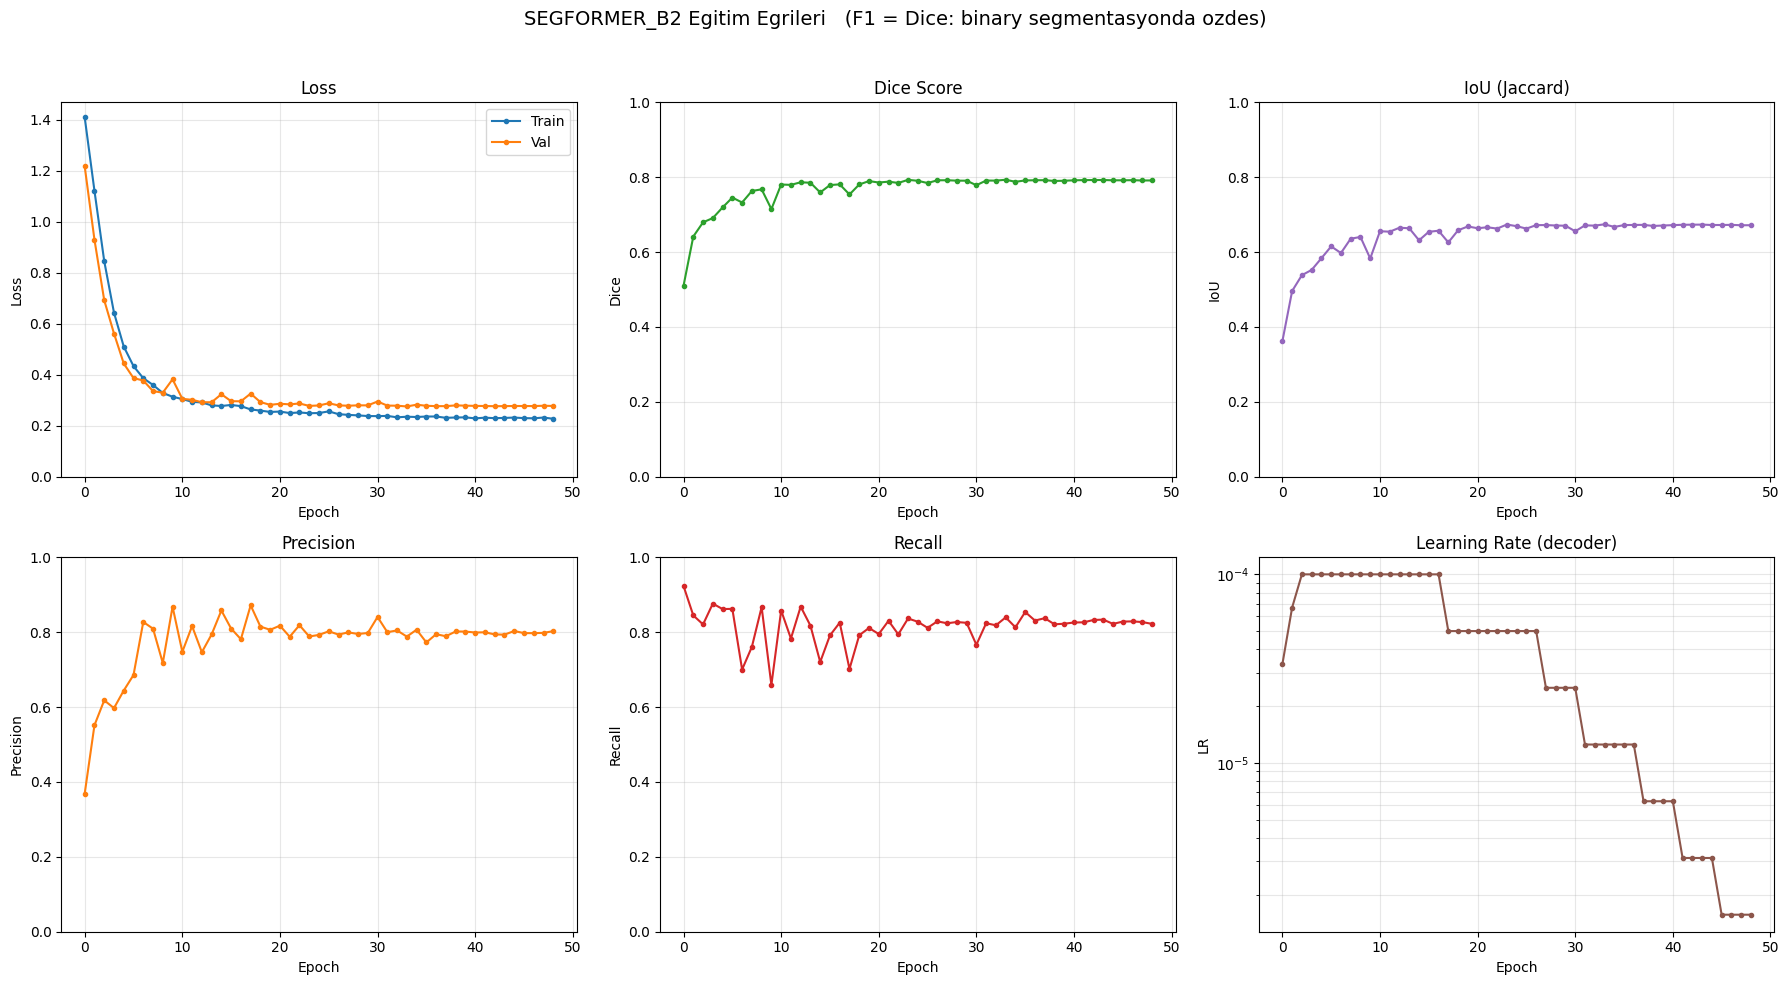

Grafikler kaydedildi: /content/drive/MyDrive/density_segmentation/segformer_b2/segformer_b2_curves.png


In [66]:
plot_training_curves(EXCEL_LOG, CURVES_PNG, MODEL_KEY.upper())
mirror_to_local(CURVES_PNG)
print('Grafikler kaydedildi:', CURVES_PNG)

## 5 Sabit Vaka Görseli (Orijinal | Ground Truth | Tahmin)

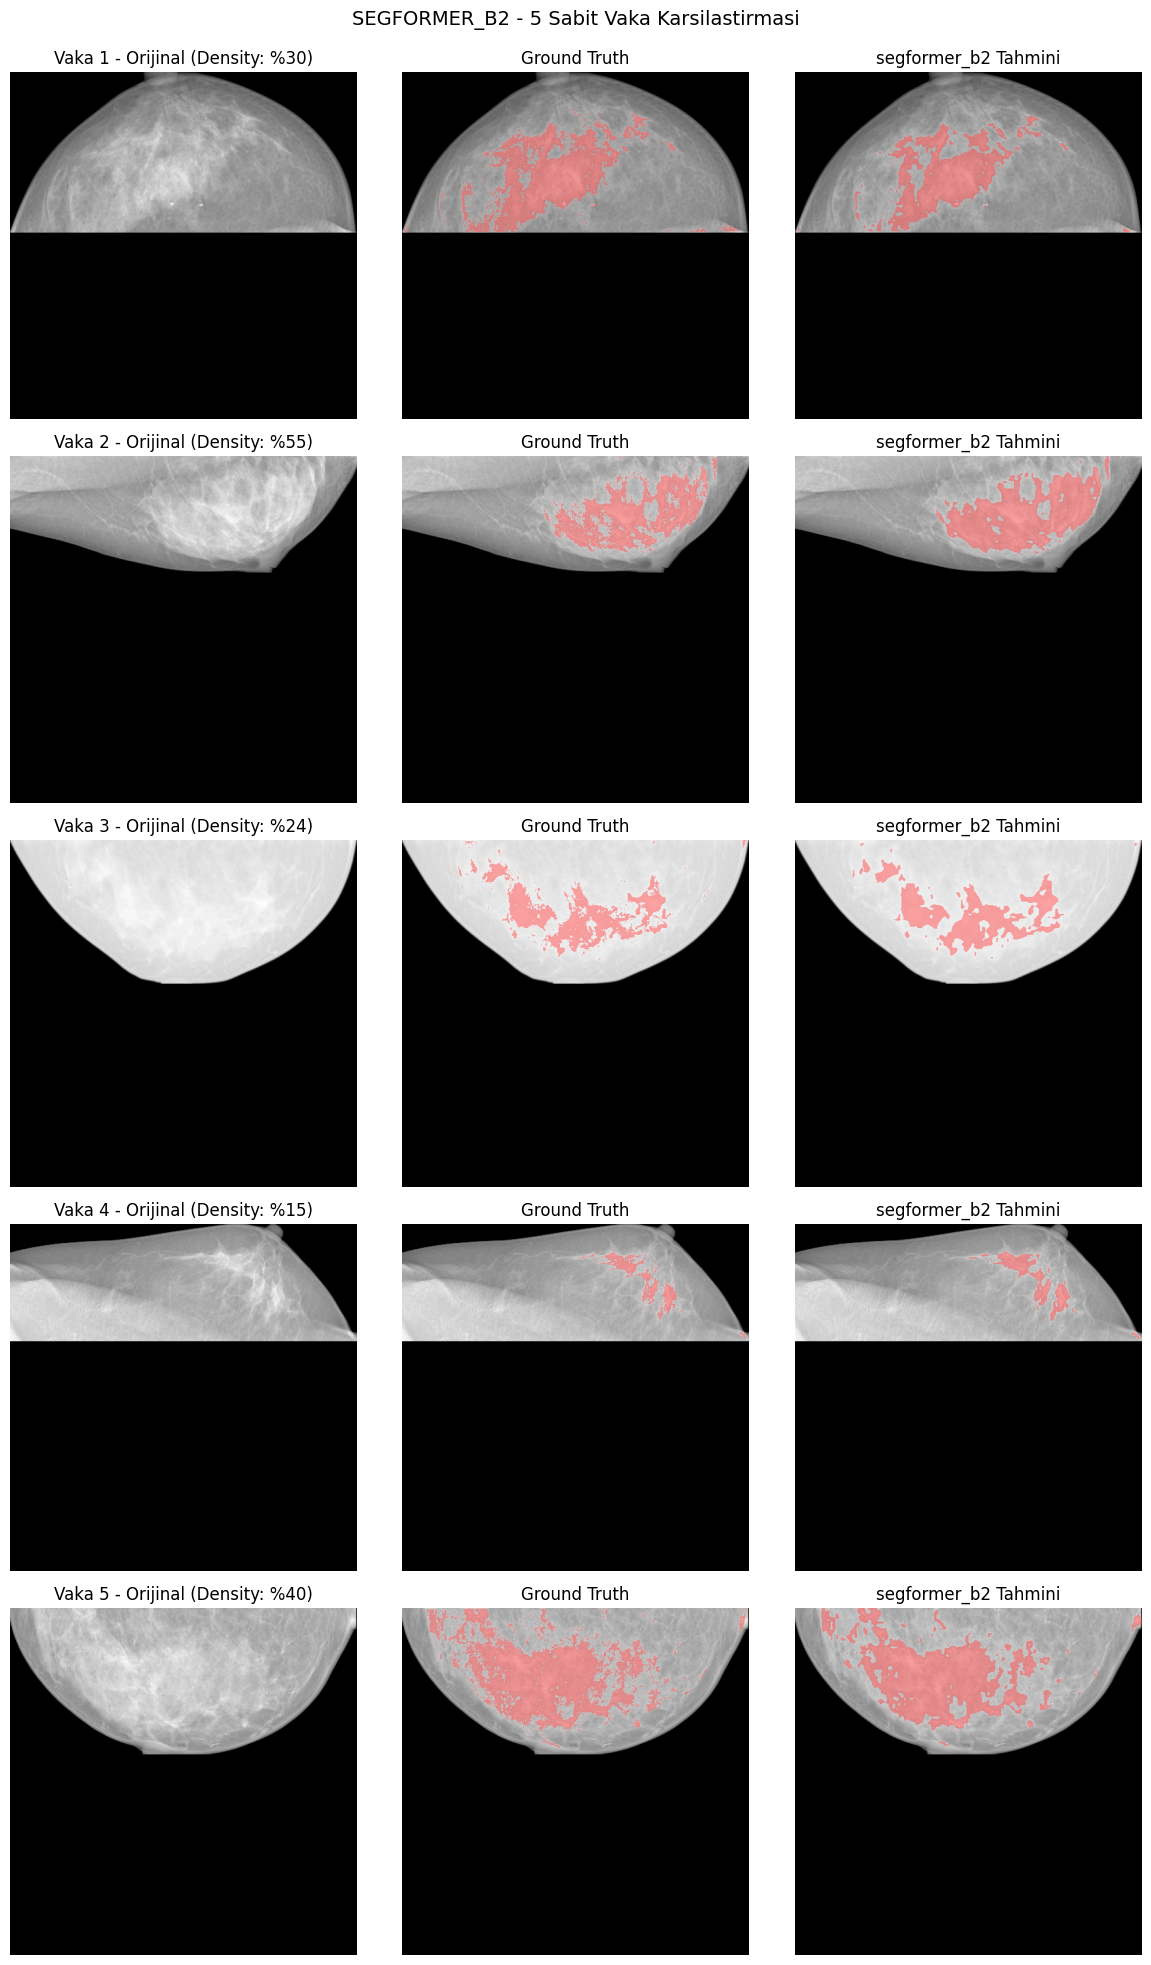

Vaka gorselleri kaydedildi: /content/drive/MyDrive/density_segmentation/segformer_b2/segformer_b2_cases/segformer_b2_5cases.png


In [67]:
val_lookup = {c[0]: (c[1], c[2]) for c in val_index}
raw_val_transform = A.Compose([A.Resize(IMAGE_SIZE, IMAGE_SIZE)])  # gorsellestirme icin normalize'siz kopya
predict_transform = A.Compose([imagenet_normalize(), ToTensorV2()])  # egitimdekiyle ayni normalize


def overlay_mask(ax, base_gray, mask, rgb=(1.0, 0.2, 0.2), alpha=0.45):
    # cmap='Reds' maskenin 0 oldugu her pikseli BEYAZ boyuyordu; alpha ile tum
    # panele beyaz pece cekilip mamografi detayi soluyordu (orijinal panelin
    # arka plani siyah, GT/tahmin panellerininki gri cikiyordu). Simdi sadece
    # mask==1 pikselleri renkli, geri kalani tamamen seffaf.
    ax.imshow(base_gray, cmap='gray')
    rgba = np.zeros((*mask.shape, 4), dtype=np.float32)
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = rgb
    rgba[..., 3] = (mask > 0.5) * alpha
    ax.imshow(rgba)


@torch.no_grad()
def predict_mask(img_norm_3ch):
    tensor = predict_transform(image=img_norm_3ch)['image'].unsqueeze(0).to(DEVICE)
    model.eval()
    logits = model(tensor)
    return (torch.sigmoid(logits)[0, 0] > 0.5).cpu().numpy()


fig, axes = plt.subplots(len(EVAL_CASE_IDS), 3, figsize=(12, 4 * len(EVAL_CASE_IDS)))
if len(EVAL_CASE_IDS) == 1:
    axes = axes[None, :]

for row_i, case_id in enumerate(EVAL_CASE_IDS):
    img_path, lbl_path = val_lookup[case_id]
    img = nib.load(img_path).get_fdata().astype(np.float32)
    lbl = nib.load(lbl_path).get_fdata().astype(np.float32)
    img_norm = (img - img.min()) / (img.max() - img.min() + 1e-8)

    resized = raw_val_transform(image=np.stack([img_norm] * 3, axis=-1), mask=lbl)
    img_resized, lbl_resized = resized['image'], resized['mask']
    pred_mask = predict_mask(img_resized)

    density_pct = val_density.get(case_id, None)
    title_suffix = f' (Density: %{density_pct:.0f})' if density_pct is not None else ''

    axes[row_i, 0].imshow(img_resized[..., 0], cmap='gray')
    axes[row_i, 0].set_title(f'Vaka {row_i+1} - Orijinal{title_suffix}')
    overlay_mask(axes[row_i, 1], img_resized[..., 0], lbl_resized)
    axes[row_i, 1].set_title('Ground Truth')
    overlay_mask(axes[row_i, 2], img_resized[..., 0], pred_mask)
    axes[row_i, 2].set_title(f'{MODEL_KEY} Tahmini')

    for ax in axes[row_i]:
        ax.axis('off')

plt.suptitle(f'{MODEL_KEY.upper()} - 5 Sabit Vaka Karsilastirmasi', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.985])  # suptitle ilk satirin basliklarini eziyordu
cases_png = f'{CASES_DIR}/{MODEL_KEY}_5cases.png'
plt.savefig(cases_png, dpi=150, bbox_inches='tight')
plt.show()
mirror_to_local(cases_png)
print('Vaka gorselleri kaydedildi:', cases_png)